In [ ]:
!pip install pandas
!pip install numpy
!pip install seaborn
!pip install matplotlib
!pip install scikit-learn

In [ ]:
import pandas as pd          # data handling
import numpy as np           # numerical operations
import seaborn as sns        # visualisation
import matplotlib.pyplot as plt  # plotting

from sklearn.model_selection import train_test_split   # split data
from sklearn.preprocessing import StandardScaler       # feature scaling
from sklearn.neighbors import KNeighborsClassifier     # KNN (supervised)
from sklearn.cluster import KMeans                     # K-Means (unsupervised)
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
file_path = '/content/BANK LOAN.csv'   # adjust if needed
df = pd.read_csv(file_path)

df.head()

,SN,AGE,EMPLOY,ADDRESS,DEBTINC,CREDDEBT,OTHDEBT,DEFAULTER
0,1,3,17,12,9.3,11.36,5.01,1
1,2,1,10,6,17.3,1.36,4.00,0
2,3,2,15,14,5.5,0.86,2.17,0
3,4,3,15,14,2.9,2.66,0.82,0
4,5,1,2,0,17.3,1.79,3.06,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   SN         700 non-null    int64  
 1   AGE        700 non-null    int64  
 2   EMPLOY     700 non-null    int64  
 3   ADDRESS    700 non-null    int64  
 4   DEBTINC    700 non-null    float64
 5   CREDDEBT   700 non-null    float64
 6   OTHDEBT    700 non-null    float64
 7   DEFAULTER  700 non-null    int64  
dtypes: float64(3), int64(5)
memory usage: 43.9 KB


In [ ]:
df.describe()

,SN,AGE,EMPLOY,ADDRESS,DEBTINC,CREDDEBT,OTHDEBT,DEFAULTER
count,700.00000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,350.50000,1.902857,8.388571,8.278571,10.260571,1.553457,3.058229,0.261429
std,202.21688,0.765301,6.658039,6.824877,6.827234,2.117209,3.287524,0.439727
min,1.00000,1.000000,0.000000,0.000000,0.400000,0.010000,0.050000,0.000000
25%,175.75000,1.000000,3.000000,3.000000,5.000000,0.370000,1.047500,0.000000
50%,350.50000,2.000000,7.000000,7.000000,8.600000,0.855000,1.985000,0.000000
75%,525.25000,2.000000,12.000000,12.000000,14.125000,1.905000,3.927500,1.000000
max,700.00000,3.000000,31.000000,34.000000,41.300000,20.560000,27.030000,1.000000


In [ ]:
df['DEFAULTER'].value_counts()

,count
DEFAULTER,
0,517
1,183


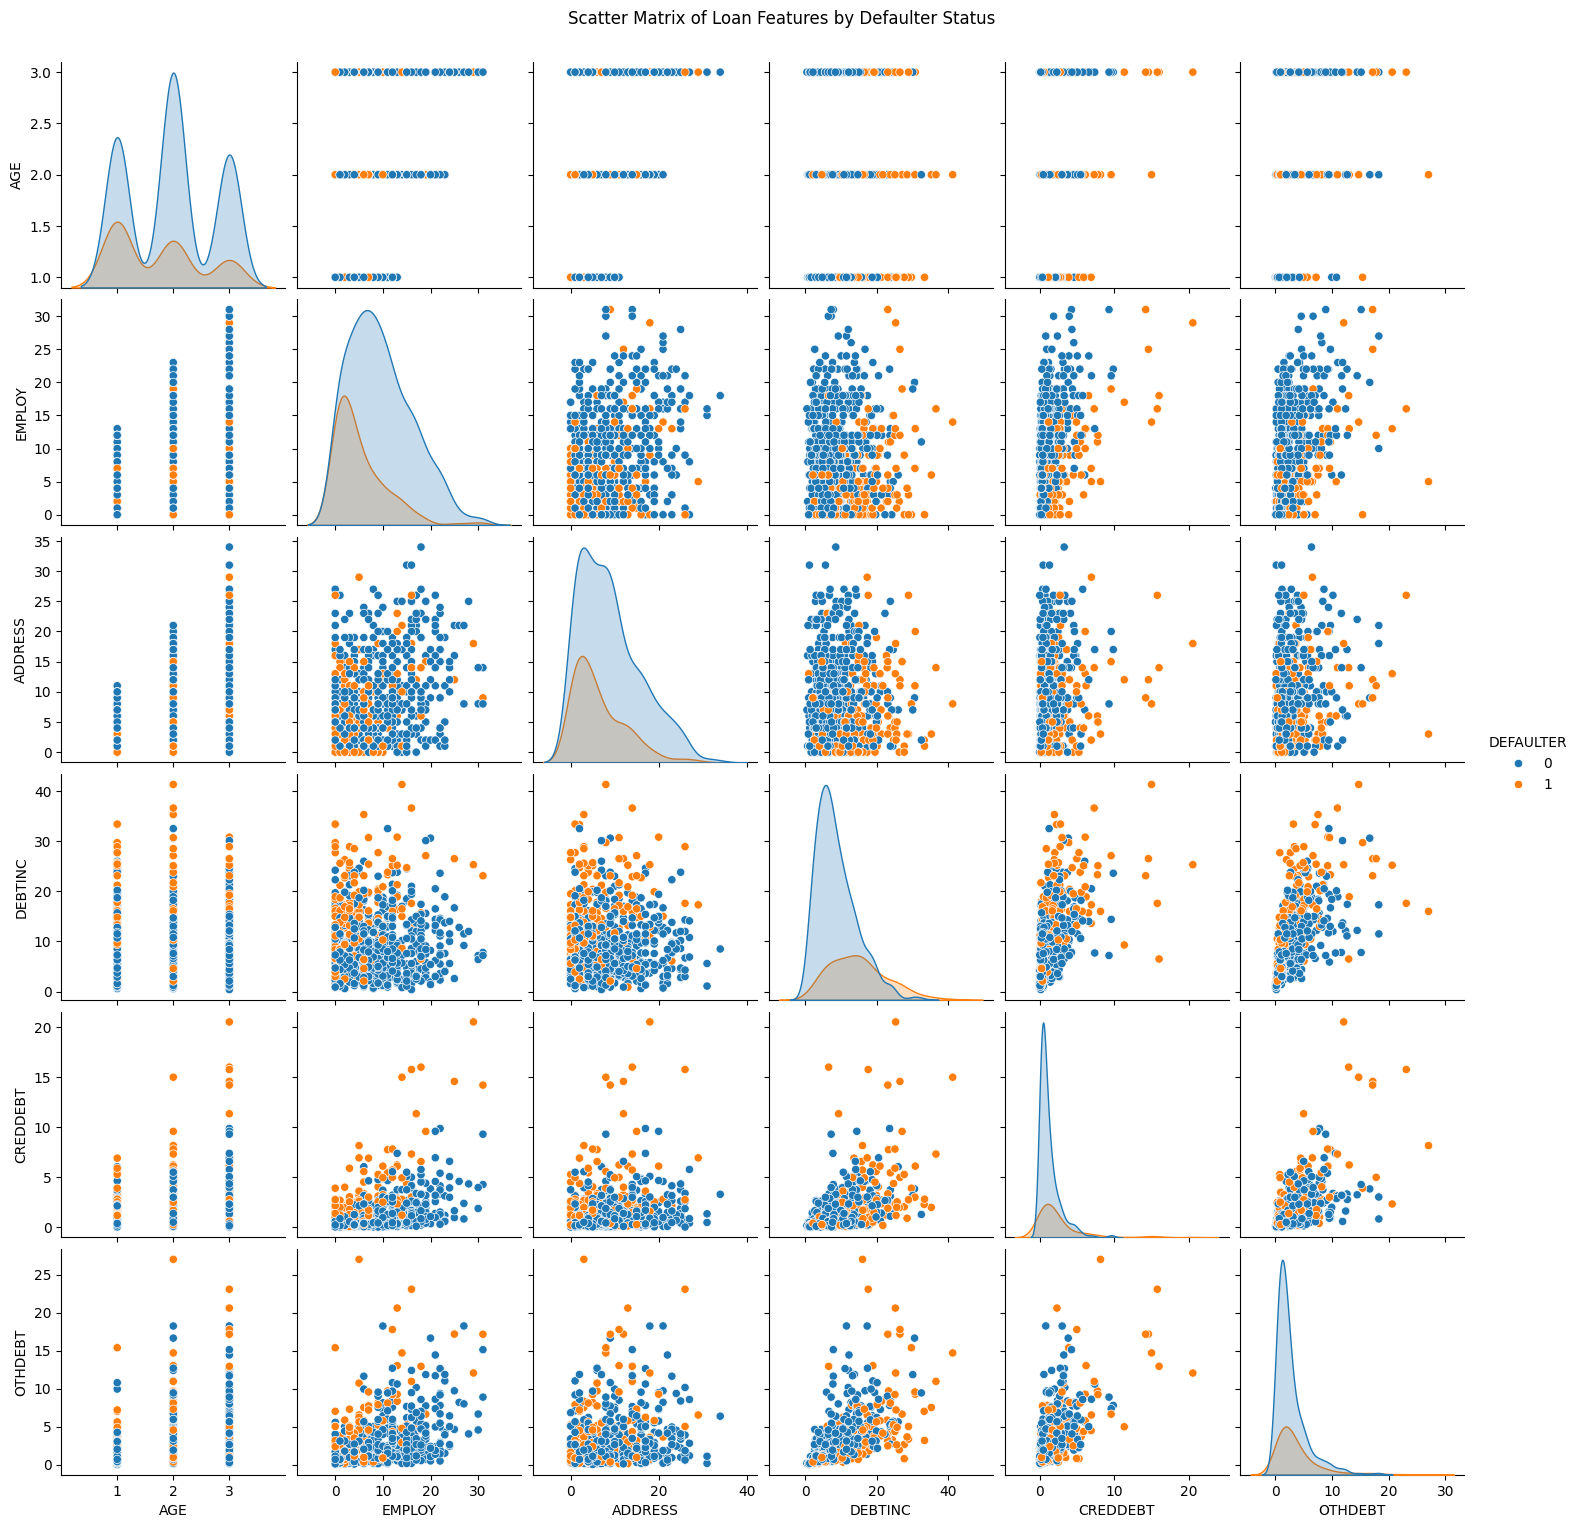

In [ ]:
sns.pairplot(df[['AGE', 'EMPLOY', 'ADDRESS', 'DEBTINC', 'CREDDEBT', 'OTHDEBT', 'DEFAULTER']],
             hue='DEFAULTER',
             diag_kind='kde')
plt.suptitle('Scatter Matrix of Loan Features by Defaulter Status', y=1.02)
plt.show()

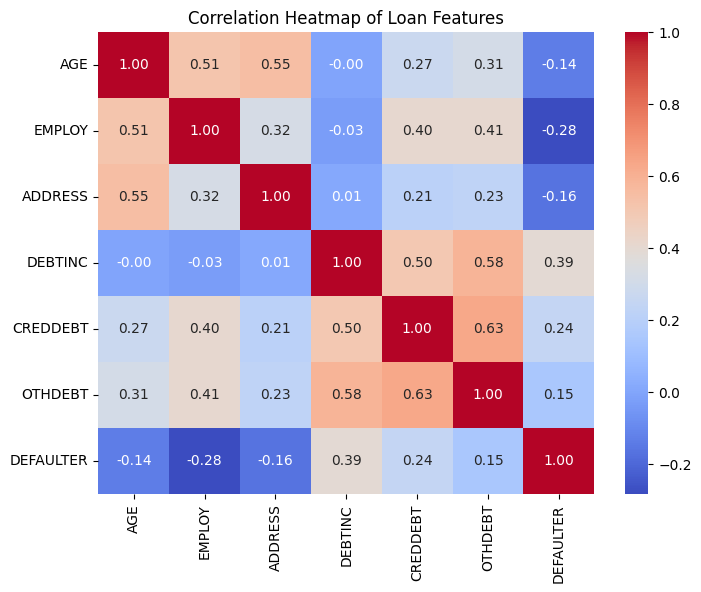

In [ ]:
plt.figure(figsize=(8,6))
corr = df[['AGE', 'EMPLOY', 'ADDRESS', 'DEBTINC', 'CREDDEBT', 'OTHDEBT', 'DEFAULTER']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Loan Features')
plt.show()

In [ ]:
feature_cols = ['AGE', 'EMPLOY', 'ADDRESS', 'DEBTINC', 'CREDDEBT', 'OTHDEBT']
X = df[feature_cols].values
y = df['DEFAULTER'].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,       # 30% test, 70% train
    random_state=42,     # reproducible split
    stratify=y           # keep same class ratio in train and test
)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)

In [ ]:
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [ ]:
y_pred_knn = knn.predict(X_test_scaled)

In [ ]:
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy:", accuracy_knn)

print("\nConfusion Matrix (KNN):")
print(confusion_matrix(y_test, y_pred_knn))

print("\nClassification Report (KNN):")
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.7476190476190476

Confusion Matrix (KNN):
[[132  23]
 [ 30  25]]

Classification Report (KNN):
              precision    recall  f1-score   support

           0       0.81      0.85      0.83       155
           1       0.52      0.45      0.49        55

    accuracy                           0.75       210
   macro avg       0.67      0.65      0.66       210
weighted avg       0.74      0.75      0.74       210



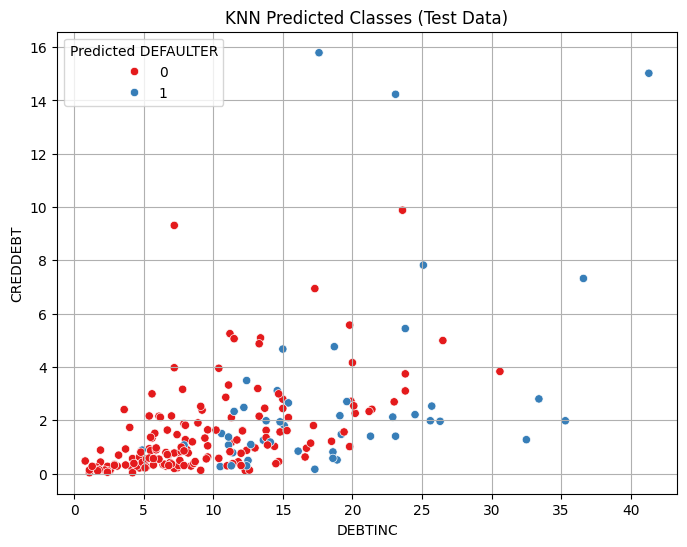

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_test[:, feature_cols.index('DEBTINC')],
    y=X_test[:, feature_cols.index('CREDDEBT')],
    hue=y_pred_knn,
    palette='Set1'
)
plt.xlabel('DEBTINC')
plt.ylabel('CREDDEBT')
plt.title('KNN Predicted Classes (Test Data)')
plt.legend(title='Predicted DEFAULTER')
plt.grid(True)
plt.show()

In [ ]:
X_scaled = scaler.fit_transform(X)   # scale all data for clustering

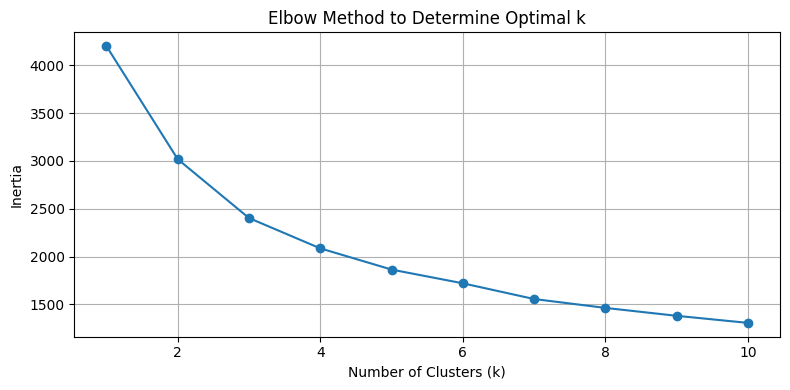

In [ ]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42)
    kmeans_temp.fit(X_scaled)
    inertia.append(kmeans_temp.inertia_)

plt.figure(figsize=(8,4))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method to Determine Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
k = 2
kmeans = KMeans(n_clusters=k, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
centroids_scaled = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)
centroid_df = pd.DataFrame(centroids, columns=feature_cols)
centroid_df

,AGE,EMPLOY,ADDRESS,DEBTINC,CREDDEBT,OTHDEBT
0,1.654902,5.984314,6.374510,8.716078,0.855902,1.762882
1,2.568421,14.842105,13.389474,14.406316,3.425842,6.535211


In [ ]:
cross_tab = pd.crosstab(df['Cluster'], df['DEFAULTER'])
cross_tab

DEFAULTER,0,1
Cluster,,
0,375,135
1,142,48


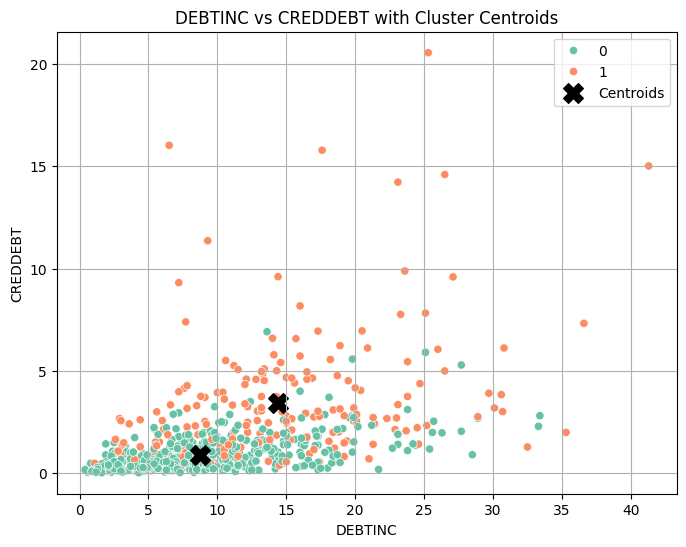

In [ ]:
x_feature = 'DEBTINC'
y_feature = 'CREDDEBT'

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x=x_feature,
    y=y_feature,
    hue='Cluster',
    palette='Set2'
)

plt.scatter(
    centroid_df[x_feature],
    centroid_df[y_feature],
    s=200,
    c='black',
    marker='X',
    label='Centroids'
)

plt.title(f'{x_feature} vs {y_feature} with Cluster Centroids')
plt.xlabel(x_feature)
plt.ylabel(y_feature)
plt.legend()
plt.grid(True)
plt.show()

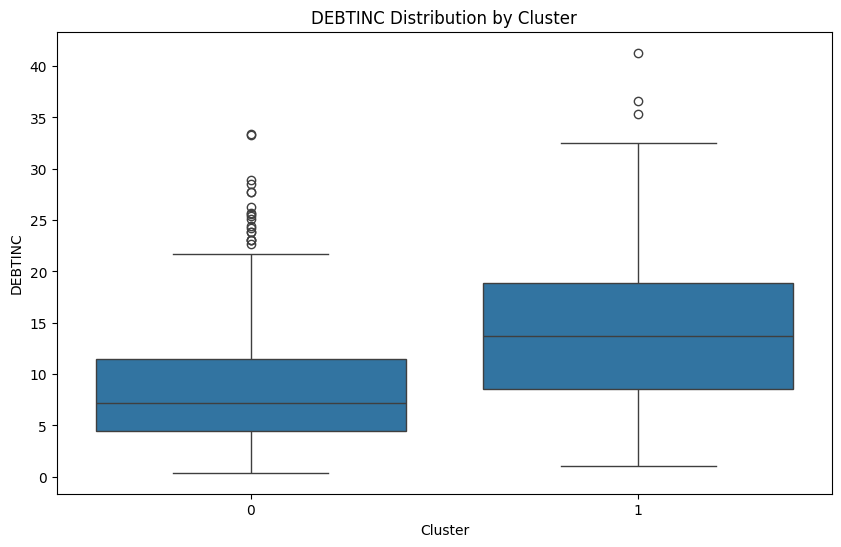

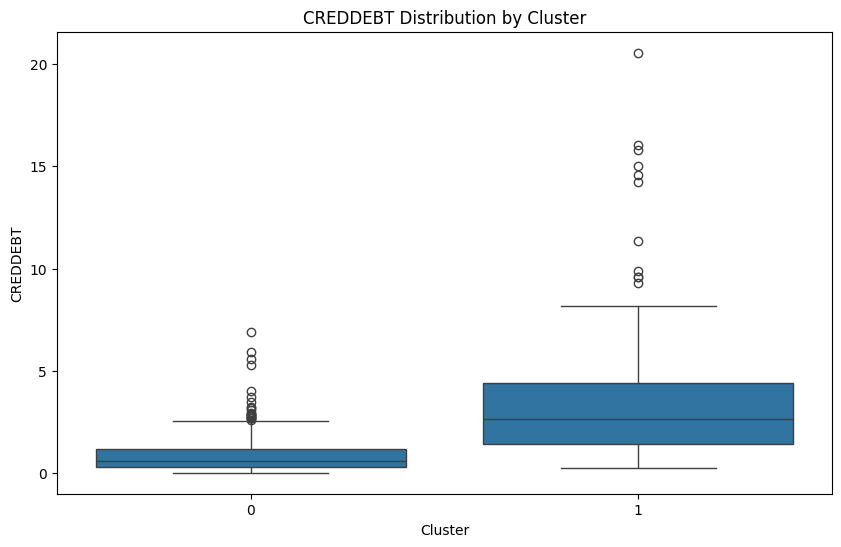

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Cluster', y='DEBTINC')
plt.title('DEBTINC Distribution by Cluster')
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Cluster', y='CREDDEBT')
plt.title('CREDDEBT Distribution by Cluster')
plt.show()

**- Which is better for this dataset?**
- For **prediction of default** → **KNN** is better, because it directly learns from labelled examples.
- For **exploring structure** and **risk profiles **→** K-Means** is helpful to understand patterns and segments.
- You can conclude:
- “For this **bank loan dataset**, **KNN is more suitable for predicting defaulters**, while **K-Means is useful for understanding customer groups and risk levels**. Both methods together give a complete picture.”
